In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, f1_score, recall_score,
    precision_score, precision_recall_curve, average_precision_score
)

import lightgbm as lgb
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
RECALL_TARGET = 0.90   
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
print(f"✅ Imports done. Recall target: {RECALL_TARGET}")


✅ Imports done. Recall target: 0.9


In [2]:
df = pd.read_csv("elbehiry.csv")
print("Shape:", df.shape)

for col in ["CustomerID", "ID"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"  Dropped: {col}")

churn_rate = df["Churn"].mean()
imbalance  = (1 - churn_rate) / churn_rate
print(f"\nChurn rate: {churn_rate:.3f}  |  Imbalance ratio: {imbalance:.1f}:1")
display(df.describe())


Shape: (15000, 9)
  Dropped: CustomerID

Churn rate: 0.179  |  Imbalance ratio: 4.6:1


,Age,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Support_Calls,Churn
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,43.452667,35.964000,182.520000,60.293267,4995.762320,4.520200,0.178867
std,14.910732,20.543493,104.731357,34.391762,3957.085534,2.884513,0.383253
min,18.000000,1.000000,1.000000,1.000000,15.770000,0.000000,0.000000
25%,31.000000,18.000000,92.000000,30.000000,1803.005000,2.000000,0.000000
50%,43.000000,36.000000,183.000000,60.000000,3896.720000,5.000000,0.000000
75%,56.000000,54.000000,273.000000,90.000000,7439.232500,7.000000,0.000000
max,69.000000,71.000000,364.000000,119.000000,17617.700000,9.000000,1.000000


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("Churn")

# ── Outlier capping ──────────────────────────────────────────────────────────
def cap_iqr(data, col, factor=1.5):
    q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    iqr = q3 - q1
    data[col] = np.clip(data[col], q1 - factor*iqr, q3 + factor*iqr)

for col in numeric_cols:
    cap_iqr(df, col)

# ── Ratio features ───────────────────────────────────────────────────────────
freq = df["Frequency"] + 1e-3
df["Revenue_per_txn"]      = df["Monetary_Value"]  / freq
df["SupportCalls_per_txn"] = df["Support_Calls"]   / freq
df["Recency_per_txn"]      = df["Recency_Days"]    / freq
df["Tenure_per_txn"]       = df["Tenure_Months"]   / freq

# ── Interaction features (NEW) ───────────────────────────────────────────────
df["Support_x_Recency"]    = df["Support_Calls"]  * df["Recency_Days"]   
df["Revenue_x_Tenure"]     = df["Monetary_Value"] * df["Tenure_Months"]  
df["Support_x_LowTenure"]  = df["Support_Calls"]  * (1 / (df["Tenure_Months"] + 1)) 

# ── Binary flags ─────────────────────────────────────────────────────────────
df["HighSupportCalls"] = (df["Support_Calls"] >= 7).astype(int)
df["LowTenure"]        = (df["Tenure_Months"] <= 6).astype(int)
df["HighRecency"]      = (df["Recency_Days"]  >= 300).astype(int)
df["LowFrequency"]     = (df["Frequency"]    <= 10).astype(int)
df["HighSupport_AND_HighRecency"] = (
    (df["Support_Calls"] >= 7) & (df["Recency_Days"] >= 300)
).astype(int)

print(f"✅ Feature engineering done. Total features: {df.shape[1] - 1}")
print("\nNew features added:")
new_feats = ["Revenue_per_txn","SupportCalls_per_txn","Recency_per_txn","Tenure_per_txn",
             "Support_x_Recency","Revenue_x_Tenure","Support_x_LowTenure",
             "HighSupportCalls","LowTenure","HighRecency","LowFrequency","HighSupport_AND_HighRecency"]
for f in new_feats:
    print(f"  {f}")


✅ Feature engineering done. Total features: 19

New features added:
  Revenue_per_txn
  SupportCalls_per_txn
  Recency_per_txn
  Tenure_per_txn
  Support_x_Recency
  Revenue_x_Tenure
  Support_x_LowTenure
  HighSupportCalls
  LowTenure
  HighRecency
  LowFrequency
  HighSupport_AND_HighRecency


In [4]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

numeric_features     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}  — churn rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}   — churn rate: {y_test.mean():.3f}")

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f"scale_pos_weight: {SCALE_POS_WEIGHT:.2f}")


Train: (12000, 19)  — churn rate: 0.179
Test:  (3000, 19)   — churn rate: 0.179
scale_pos_weight: 4.59


In [5]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", RobustScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])


In [ ]:
def find_recall_threshold(y_true, y_proba, target_recall=0.90, min_precision=0.40):
    """
    Find the highest threshold where recall >= target_recall AND precision >= min_precision.
    Higher threshold = more selective = higher precision (while still meeting recall target).
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    best_thresh, best_f1 = thresholds[0], 0.0
    best_prec, best_rec  = precisions[0], recalls[0]

    for prec, rec, thr in zip(precisions[:-1], recalls[:-1], thresholds):
        if rec >= target_recall and prec >= min_precision:
            f1 = 2 * prec * rec / (prec + rec + 1e-8)
            if thr > best_thresh:  
                best_thresh = thr
                best_f1     = f1
                best_prec   = prec
                best_rec    = rec

    return float(best_thresh), float(best_prec), float(best_rec), float(best_f1)


def evaluate(name, pipe, X_te, y_te, target_recall=RECALL_TARGET):
    y_proba = pipe.predict_proba(X_te)[:, 1]
    thr, prec, rec, f1 = find_recall_threshold(y_te, y_proba, target_recall)
    y_pred  = (y_proba >= thr).astype(int)
    acc     = accuracy_score(y_te, y_pred)
    auc     = roc_auc_score(y_te, y_proba)
    ap      = average_precision_score(y_te, y_proba)
    print(f"  {name:<28} AUC={auc:.4f}  AP={ap:.4f}  Recall={rec:.4f}  Prec={prec:.4f}  F1={f1:.4f}  Acc={acc:.4f}  thr={thr:.3f}")
    return dict(model=name, AUC=auc, AP=ap, Recall=rec, Precision=prec, F1=f1, Accuracy=acc, Threshold=thr)


In [ ]:
baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced", C=1.0
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        class_weight="balanced", max_depth=20, min_samples_leaf=2
    ),
    "LightGBM": lgb.LGBMClassifier(
        random_state=RANDOM_STATE, n_estimators=500,
        learning_rate=0.05, num_leaves=63,
        is_unbalance=True,      
        min_child_samples=20, n_jobs=-1, verbose=-1
    ),
}

trained_baseline = {}
results_baseline = []
print(f"{'Model':<28} {'AUC':>6}  {'AP':>6}  {'Recall':>7}  {'Prec':>6}  {'F1':>6}  {'Acc':>6}  {'thr':>5}")
print("-" * 80)

for name, model in baseline_models.items():
    pipe = ImbPipeline([
        ("preprocess", make_preprocessor()),
        ("smote",      SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model",      model),
    ])
    pipe.fit(X_train, y_train)
    trained_baseline[name] = pipe
    results_baseline.append(evaluate(name, pipe, X_test, y_test))

baseline_df = pd.DataFrame(results_baseline).sort_values("Recall", ascending=False)
print("\n=== Baseline Summary ===")
display(baseline_df)


Model                           AUC      AP   Recall    Prec      F1     Acc    thr
--------------------------------------------------------------------------------
  LogisticRegression           AUC=0.9377  AP=0.7828  Recall=0.9013  Prec=0.5325  F1=0.6694  Acc=0.8407  thr=0.425
  RandomForest                 AUC=0.9282  AP=0.7380  Recall=0.9013  Prec=0.4964  F1=0.6402  Acc=0.8187  thr=0.259
  LightGBM                     AUC=0.9278  AP=0.7428  Recall=0.9013  Prec=0.4859  F1=0.6314  Acc=0.8117  thr=0.073

=== Baseline Summary ===


,model,AUC,AP,Recall,Precision,F1,Accuracy,Threshold
0,LogisticRegression,0.937714,0.782753,0.901304,0.532453,0.669433,0.840667,0.424762
1,RandomForest,0.928170,0.737959,0.901304,0.496410,0.640212,0.818667,0.259000
2,LightGBM,0.927845,0.742778,0.901304,0.485944,0.631442,0.811667,0.072828


In [8]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

prep = make_preprocessor()
X_train_proc = prep.fit_transform(X_train, y_train)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train_proc, y_train)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 400), 
        "learning_rate":     trial.suggest_float("learning_rate", 0.05, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 100),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
        "is_unbalance":      True,
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_resampled, y_resampled,
                             cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean()

print("🔍 Running Optuna (50 trials, 3-fold CV)... ~3-5 mins")
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)  # ← 50 not 100

print(f"\n✅ Best CV F1: {study.best_value:.4f}")
print("Best params:", study.best_params)

🔍 Running Optuna (50 trials, 3-fold CV)... ~3-5 mins


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best CV F1: 0.9292
Best params: {'n_estimators': 342, 'learning_rate': 0.20099139049748496, 'num_leaves': 61, 'max_depth': 8, 'min_child_samples': 18, 'subsample': 0.7447957894300917, 'colsample_bytree': 0.983785970996011, 'reg_alpha': 0.0002027503042499559, 'reg_lambda': 0.00014797460327562866}


In [9]:
best_lgbm_params = {**study.best_params, "random_state": RANDOM_STATE,
                    "n_jobs": -1, "verbose": -1, "is_unbalance": True}

tuned_lgbm_pipe = ImbPipeline([
    ("preprocess", make_preprocessor()),
    ("adasyn",     ADASYN(random_state=RANDOM_STATE)),   
    ("model",      lgb.LGBMClassifier(**best_lgbm_params)),
])
tuned_lgbm_pipe.fit(X_train, y_train)
print("✅ Tuned LightGBM trained.")

res_tuned = evaluate("LightGBM_Tuned", tuned_lgbm_pipe, X_test, y_test)


✅ Tuned LightGBM trained.
  LightGBM_Tuned               AUC=0.9239  AP=0.7298  Recall=0.9013  Prec=0.4736  F1=0.6209  Acc=0.8030  thr=0.015


,model,AUC,AP,Recall,Precision,F1,Accuracy,Threshold
0,LogisticRegression,0.9377,0.7828,0.9013,0.5325,0.6694,0.8407,0.4248
1,RandomForest,0.9282,0.7380,0.9013,0.4964,0.6402,0.8187,0.2590
2,LightGBM,0.9278,0.7428,0.9013,0.4859,0.6314,0.8117,0.0728
3,LightGBM_Tuned,0.9239,0.7298,0.9013,0.4736,0.6209,0.8030,0.0147


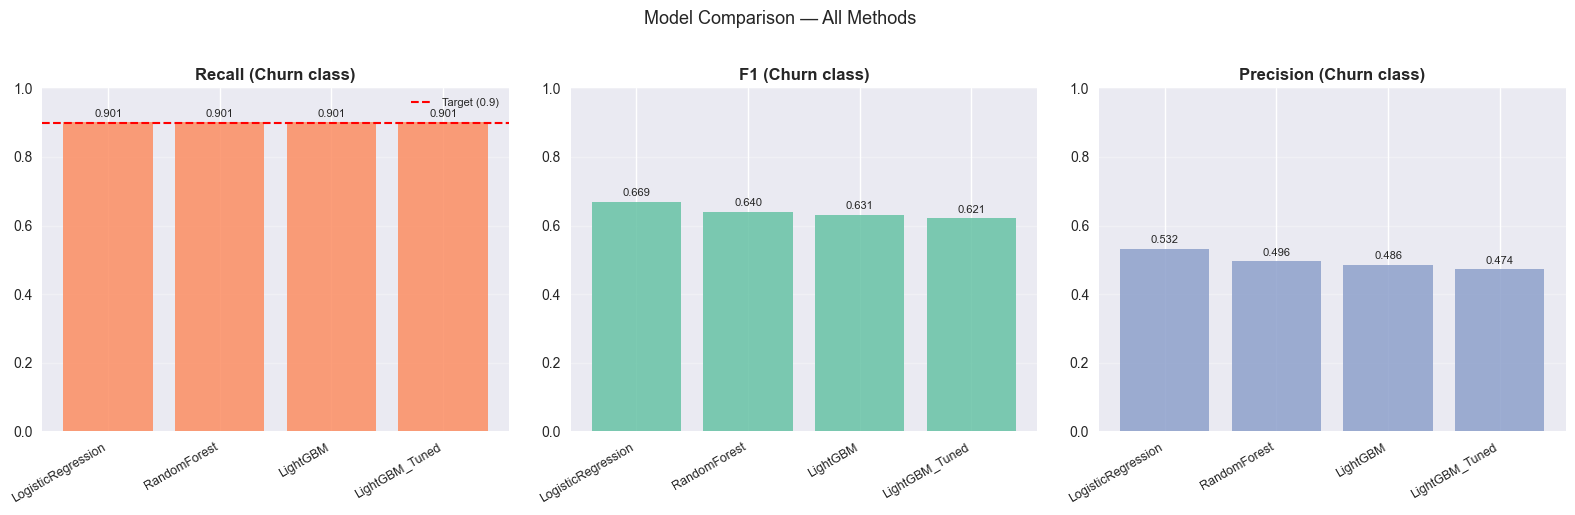

In [10]:
all_results = results_baseline + [res_tuned]
all_df = pd.DataFrame(all_results).sort_values("Recall", ascending=False)
display(all_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_list = all_df["model"].tolist()
x = np.arange(len(models_list))

for ax, metric, color in zip(axes,
    ["Recall", "F1", "Precision"],
    ["#fc8d62", "#66c2a5", "#8da0cb"]):
    bars = ax.bar(x, all_df[metric], color=color, alpha=0.85)
    ax.set_title(metric + " (Churn class)", fontsize=12, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=30, ha="right", fontsize=9)
    ax.set_ylim([0, 1])
    ax.grid(axis="y", alpha=0.3)
    if metric == "Recall":
        ax.axhline(RECALL_TARGET, color="red", linestyle="--",
                   linewidth=1.5, label=f"Target ({RECALL_TARGET})")
        ax.legend(fontsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("Model Comparison — All Methods", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



  Best model: LogisticRegression  (threshold: 0.425)

=== Classification Report ===
              precision    recall  f1-score   support

    Retained     0.9747    0.8274    0.8950      2463
     Churned     0.5325    0.9013    0.6694       537

    accuracy                         0.8407      3000
   macro avg     0.7536    0.8644    0.7822      3000
weighted avg     0.8955    0.8407    0.8547      3000


=== Confusion Matrix ===


,Pred Retained,Pred Churned
Actual Retained,2038,425
Actual Churned,53,484



  Churners caught  : 484/537 (90.1%)
  Churners missed  : 53/537 (9.9%)
  False alarms     : 425


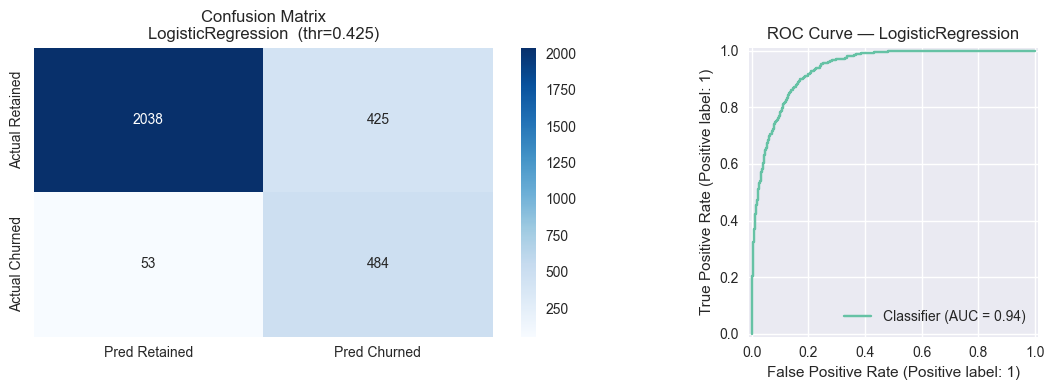

In [11]:
best_row  = all_df.iloc[0]
best_name = best_row["model"]
best_thr  = best_row["Threshold"]

pipe_map = {**trained_baseline,
            "LightGBM_Tuned":   tuned_lgbm_pipe}
best_pipe = pipe_map[best_name]

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= best_thr).astype(int)

print(f"\n{'='*60}")
print(f"  Best model: {best_name}  (threshold: {best_thr:.3f})")
print(f"{'='*60}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4,
                             target_names=["Retained", "Churned"]))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
    index=["Actual Retained","Actual Churned"],
    columns=["Pred Retained","Pred Churned"])
print("\n=== Confusion Matrix ===")
display(cm_df)

tn, fp, fn, tp = cm.ravel()
total_churners = tp + fn
print(f"\n  Churners caught  : {tp}/{total_churners} ({tp/total_churners*100:.1f}%)")
print(f"  Churners missed  : {fn}/{total_churners} ({fn/total_churners*100:.1f}%)")
print(f"  False alarms     : {fp}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix\n{best_name}  (thr={best_thr:.3f})")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve — {best_name}")
plt.tight_layout(); plt.show()


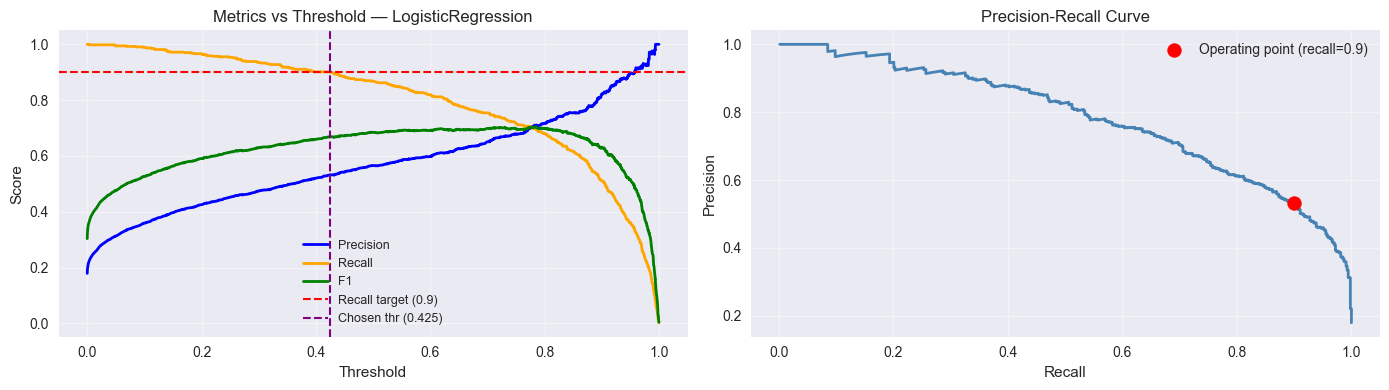

In [12]:
y_proba = best_pipe.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2*(precisions[:-1]*recalls[:-1]) / (precisions[:-1]+recalls[:-1]+1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thresholds, precisions[:-1], label="Precision", color="blue", lw=2)
axes[0].plot(thresholds, recalls[:-1],    label="Recall",    color="orange", lw=2)
axes[0].plot(thresholds, f1_scores,       label="F1",        color="green", lw=2)
axes[0].axhline(RECALL_TARGET, color="red", linestyle="--",
                label=f"Recall target ({RECALL_TARGET})", lw=1.5)
axes[0].axvline(best_thr, color="purple", linestyle="--",
                label=f"Chosen thr ({best_thr:.3f})", lw=1.5)
axes[0].set(xlabel="Threshold", ylabel="Score",
            title=f"Metrics vs Threshold — {best_name}")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.4)

axes[1].plot(recalls[:-1], precisions[:-1], lw=2, color="steelblue")
idx = np.argmin(np.abs(recalls[:-1] - RECALL_TARGET))
axes[1].scatter([recalls[idx]], [precisions[idx]], color="red", s=100, zorder=5,
                label=f"Operating point (recall={RECALL_TARGET})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()


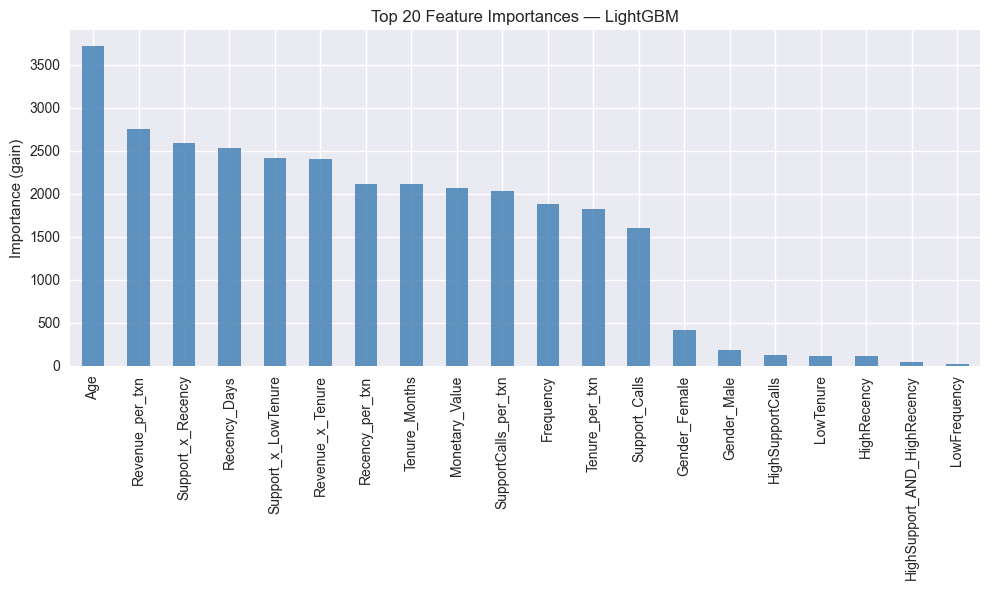


Top 10 features:
Age                     3713
Revenue_per_txn         2750
Support_x_Recency       2589
Recency_Days            2528
Support_x_LowTenure     2418
Revenue_x_Tenure        2405
Recency_per_txn         2109
Tenure_Months           2107
Monetary_Value          2061
SupportCalls_per_txn    2025


In [13]:
try:
    lgbm_pipe = trained_baseline.get("LightGBM") or tuned_lgbm_pipe
    lgbm_model = lgbm_pipe.named_steps["model"]
    prep_step  = lgbm_pipe.named_steps["preprocess"]

    num_names = numeric_features
    try:
        cat_names = list(prep_step.named_transformers_["cat"]
                         .get_feature_names_out(categorical_features))
    except Exception:
        cat_names = []
    all_names = list(num_names) + cat_names

    imp = lgbm_model.feature_importances_
    if len(imp) == len(all_names):
        feat_imp = pd.Series(imp, index=all_names).sort_values(ascending=False)
        plt.figure(figsize=(10, 6))
        feat_imp.head(20).plot(kind="bar", color="steelblue", alpha=0.85)
        plt.title("Top 20 Feature Importances — LightGBM")
        plt.ylabel("Importance (gain)")
        plt.tight_layout(); plt.show()
        print("\nTop 10 features:")
        print(feat_imp.head(10).to_string())
except Exception as e:
    print(f"Could not plot feature importances: {e}")


In [14]:
import joblib

joblib.dump(best_pipe, "elbehiry_v3_final.pkl")
np.save("elbehiry_v3_threshold.npy", best_thr)

print(f"✅ Model saved:     elbehiry_v3_final.pkl")
print(f"✅ Threshold saved: elbehiry_v3_threshold.npy  →  {best_thr:.4f}")
print()
print("=== Production usage ===")
print("  import joblib, numpy as np, pandas as pd")
print("  pipe      = joblib.load('elbehiry_v3_final.pkl')")
print("  threshold = float(np.load('elbehiry_v3_threshold.npy'))")
print("  proba     = pipe.predict_proba(X_new)[:, 1]")
print("  preds     = (proba >= threshold).astype(int)   # 1 = likely churner")

print("\n=== Final Results Summary ===")
print(all_df[["model","AUC","Recall","Precision","F1","Accuracy","Threshold"]].to_string(index=False))


✅ Model saved:     elbehiry_v3_final.pkl
✅ Threshold saved: elbehiry_v3_threshold.npy  →  0.4248

=== Production usage ===
  import joblib, numpy as np, pandas as pd
  pipe      = joblib.load('elbehiry_v3_final.pkl')
  threshold = float(np.load('elbehiry_v3_threshold.npy'))
  proba     = pipe.predict_proba(X_new)[:, 1]
  preds     = (proba >= threshold).astype(int)   # 1 = likely churner

=== Final Results Summary ===
             model      AUC   Recall  Precision       F1  Accuracy  Threshold
LogisticRegression 0.937714 0.901304   0.532453 0.669433  0.840667   0.424762
      RandomForest 0.928170 0.901304   0.496410 0.640212  0.818667   0.259000
          LightGBM 0.927845 0.901304   0.485944 0.631442  0.811667   0.072828
    LightGBM_Tuned 0.923868 0.901304   0.473581 0.620911  0.803000   0.014671
